# Aquifer Storage and Recovery: the buffer effect over repeated cycles

## Overview

A single fully-penetrating well **injects** treated freshwater into a brackish aquifer, the water spreads
as a radial bubble, and months later the **same well** **pumps it back** -- a push--pull / ASR schedule.
Mixing at the fresh/brackish interface -- microdispersion plus molecular/thermal diffusion -- means the
recovered water starts fresh and **salts up** as pumping continues. In practice you **stop extracting once
the water crosses the potable threshold**.

The interesting behaviour is over **repeated cycles**: freshwater left behind each cycle freshens the
aquifer around the well, so the next cycle's salt-up front arrives *later* -- you recover more usable
water before hitting the threshold. This is the **buffer effect**, the reason real ASR schemes ramp up
over their first years. We run three cycles and watch it happen.

`gwtransport.radial_asr` solves the **exact** radial advection-dispersion for this push--pull schedule
in an infinite aquifer (no grid, no numerical dispersion). We are not running an operational
(stop-at-threshold) controller, so we simply **preset** the signed flow schedule, on **irregular time
bins** -- coarse on the flat fresh plateau, finer as the recovered concentration starts to climb and
through the threshold, where resolution matters. Every computation includes molecular/thermal diffusion
`D_m` (dominant for heat storage / ATES). Chloride is conservative, so we transport the deviation from the
brackish background and add it back.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.radial_asr import infiltration_to_extraction

# --- Site, well, and water chemistry (chloride, mg/L) ---
SCREEN_HEIGHT = 20.0  # m, fully-penetrating well screen
POROSITY = 0.35
WELL_RADIUS = 0.3  # m
ALPHA_L = 0.5  # m, longitudinal dispersivity
MOLECULAR_DIFFUSIVITY = 0.6  # m2/day, molecular/thermal diffusion (heat/ATES scale), included throughout
C_BRACKISH = 1200.0  # native groundwater
C_FRESH = 50.0  # injected treated water
C_POTABLE = 300.0  # usable-water threshold (stop extracting above this)

GEOM = {
    "pore_heights": SCREEN_HEIGHT,
    "porosity": POROSITY,
    "well_radius": WELL_RADIUS,
    "longitudinal_dispersivity": ALPHA_L,
    "molecular_diffusivity": MOLECULAR_DIFFUSIVITY,
}
N_QUAD = 40  # radial resident-profile quadrature (the cost driver when D_m > 0)
INJECTED = 1000.0 * 90  # m3 of freshwater stored per cycle

# Recovery bins, IRREGULAR: coarse on the fresh plateau, finer as cout climbs, fine through the threshold.
RECOVER_DT = [10.0] * 4 + [5.0] * 6 + [2.0] * 15  # 40 + 30 + 30 = 100 days, 25 bins (vs 100 daily)


def schedule(n_cycles):
    """Build (flow rates, bin widths days, time edges, cin) for n_cycles of inject(90 d) + recover(100 d)."""
    segs = ([(1000.0, 90.0)] + [(-800.0, d) for d in RECOVER_DT]) * n_cycles
    flow = np.array([rate for rate, _ in segs])
    dt = np.array([days for _, days in segs])
    tedges = pd.Timestamp("2021-01-01") + pd.to_timedelta(np.concatenate([[0.0], np.cumsum(dt)]), unit="D")
    cin = np.where(flow > 0, C_FRESH, C_BRACKISH)
    return flow, dt, tedges, cin

## Three cycles: the salt-up front arrives later each time

Inject 90,000 m³, recover, repeat -- three times. Below we read out the **recovered concentration**
(`cout`) and, for each cycle, the **recovery efficiency**: the fraction of the injected volume recovered
*below* the potable threshold (i.e. what you would actually keep if you stopped at the threshold).

cycle 1: recovery efficiency 68%
cycle 2: recovery efficiency 76%
cycle 3: recovery efficiency 84%


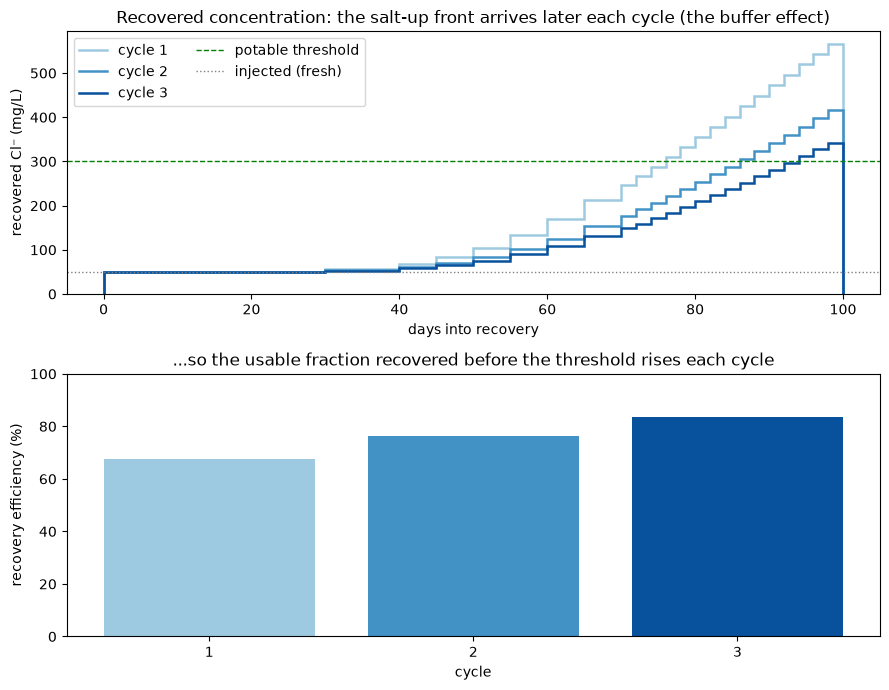

In [2]:
n_cycles = 3
flow, dt, tedges, cin = schedule(n_cycles)
cout = infiltration_to_extraction(
    cin=cin,
    flow=flow,
    tedges=tedges,
    cout_tedges=tedges,
    background=C_BRACKISH,
    n_quad=N_QUAD,
    **GEOM,  # ty: ignore[invalid-argument-type]  # the all-float dict widens against `n_modes: int | None`
)

cyc = 1 + len(RECOVER_DT)  # bins per cycle (1 injection + recovery bins)
rec_edges = np.concatenate([[0.0], np.cumsum(RECOVER_DT)])  # recovery-time bin edges (days), same each cycle
vol = np.abs(flow) * dt  # m3 per bin (irregular widths -> volume-weight)

re = []
for k in range(n_cycles):
    sl = slice(k * cyc, (k + 1) * cyc)
    f, v, c = flow[sl], vol[sl], cout[sl]
    e = f < 0
    re.append(np.sum(v[e] * (c[e] < C_POTABLE)) / INJECTED)
    print(f"cycle {k + 1}: recovery efficiency {100 * re[-1]:.0f}%")

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 7))
colors = ["#9ecae1", "#4292c6", "#08519c"]
for k in range(n_cycles):
    cout_rec = cout[k * cyc + 1 : (k + 1) * cyc]  # the recovery bins of cycle k (injection bin is NaN)
    ax0.stairs(cout_rec, rec_edges, color=colors[k], lw=1.8, label=f"cycle {k + 1}")
ax0.axhline(C_POTABLE, color="green", ls="--", lw=1, label="potable threshold")
ax0.axhline(C_FRESH, color="grey", ls=":", lw=1, label="injected (fresh)")
ax0.set_xlabel("days into recovery")
ax0.set_ylabel("recovered Cl⁻ (mg/L)")
ax0.set_title("Recovered concentration: the salt-up front arrives later each cycle (the buffer effect)")
ax0.legend(ncol=2)

ax1.bar(range(1, n_cycles + 1), [100 * r for r in re], color=colors)
ax1.set_xlabel("cycle")
ax1.set_ylabel("recovery efficiency (%)")
ax1.set_xticks(range(1, n_cycles + 1))
ax1.set_ylim(0, 100)
ax1.set_title("...so the usable fraction recovered before the threshold rises each cycle")
fig.tight_layout()
plt.show()

## What the plots show

- **Top -- the breakthrough moves right.** Each cycle the recovered water stays fresh longer and crosses
  the potable threshold (dashed) later. Operationally you would *stop extracting* where each curve meets
  the threshold; we pump a little past only to show the front. The later crossing in cycle 3 is the
  buffer: the freshwater each previous cycle left behind has freshened the near-well aquifer.
- **Bottom -- recovery efficiency climbs.** The usable fraction recovered before the threshold rises from
  cycle to cycle, the quantitative signature of the buffer and the reason real ASR yields improve over the
  first few cycles.

A few modelling notes. The flow is **preset** (we are not simulating a stop-at-threshold controller), on
**irregular time bins** that are coarse on the flat fresh plateau and fine where `cout` climbs through the
threshold -- far fewer steps than daily bins, where it matters. Recovery efficiency is volume-weighted
(`|flow|·dt`) because the bin widths vary, and the breakthrough is drawn as variable-width steps
(`ax.stairs`) -- the engine's output is a flow-weighted bin average. Everything carries molecular/thermal
diffusion `D_m`; cycles are just the sign pattern of `flow`, composed automatically.

## References

- Tang, D. H., & Babu, D. K. (1979). Analytical solution of a velocity dependent dispersion problem.
  *Water Resources Research*, 15(6), 1471-1478. — the radial mechanical-dispersion (`D = alpha_L |u|`)
  injection solution in Airy functions.
- Aichi, M., & Akitaya, K. (2018). Analytical solution for a radial advection-dispersion equation
  including both mechanical dispersion and molecular diffusion ... from a well. *Hydrological Research
  Letters*, 12(3), 23-27. — the `D = alpha_L |u| + D_m` injection kernel under the same flux boundary.

These treat a single injection; the extraction dual and the multi-cycle push--pull composition shown here
are built on top of them.